<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/DayChallenge1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Charger et prétraiter l'ensemble de données MNIST

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Charger le jeu de données MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Forme des données d'entraînement: {x_train.shape}")
print(f"Forme des étiquettes d'entraînement: {y_train.shape}")
print(f"Forme des données de test: {x_test.shape}")
print(f"Forme des étiquettes de test: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forme des données d'entraînement: (60000, 28, 28)
Forme des étiquettes d'entraînement: (60000,)
Forme des données de test: (10000, 28, 28)
Forme des étiquettes de test: (10000,)


### Normaliser les valeurs des pixels

In [2]:
# Normaliser les images pour qu'elles soient comprises entre 0 et 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Valeur min après normalisation (entraînement): {x_train.min()}")
print(f"Valeur max après normalisation (entraînement): {x_train.max()}")

Valeur min après normalisation (entraînement): 0.0
Valeur max après normalisation (entraînement): 1.0


### Convertir les étiquettes au format encodé one-hot

In [3]:
# Convertir les étiquettes en encodage one-hot
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Forme des étiquettes d'entraînement après one-hot: {y_train.shape}")
print(f"Forme des étiquettes de test après one-hot: {y_test.shape}")

Forme des étiquettes d'entraînement après one-hot: (60000, 10)
Forme des étiquettes de test après one-hot: (10000, 10)


### Afficher des exemples d'images

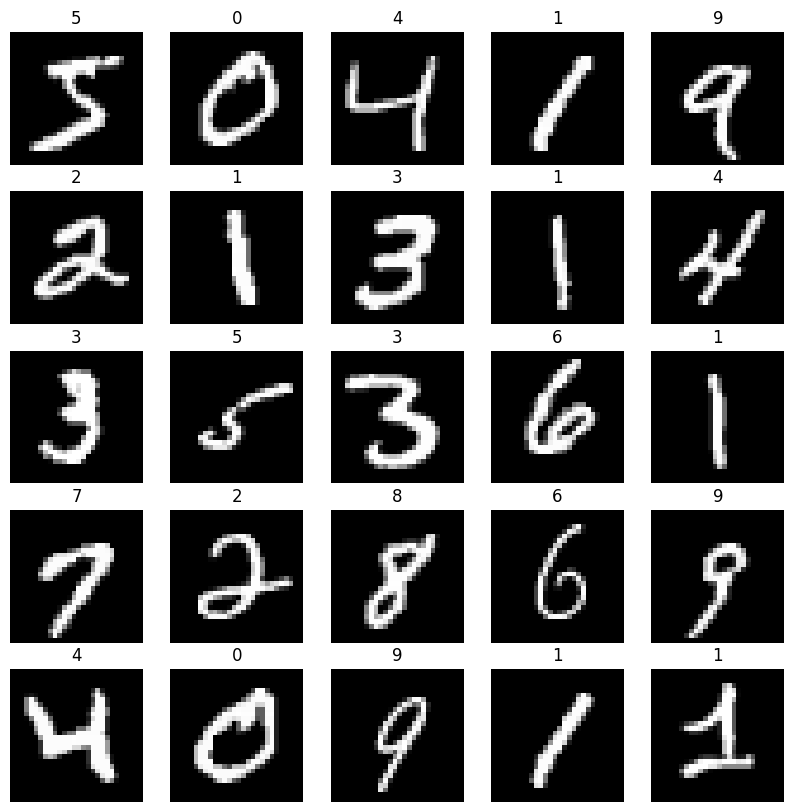

In [4]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(np.argmax(y_train[i])) # Reconvertir l'étiquette one-hot en chiffre
    plt.axis('off')
plt.show()

## 2. Construire un réseau neuronal entièrement connecté

In [5]:
from tensorflow.keras import layers, models

# Définir le modèle séquentiel
model = models.Sequential([
    # Aplatir les images 28x28 en un seul vecteur de 784 pixels
    layers.Flatten(input_shape=(28, 28)),
    # Première couche cachée avec activation ReLU
    layers.Dense(128, activation='relu'),
    # Deuxième couche cachée avec activation ReLU
    layers.Dense(64, activation='relu'),
    # Couche de sortie avec activation Softmax pour la classification multiclasse
    layers.Dense(num_classes, activation='softmax')
])

# Compiler le modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Afficher un résumé du modèle
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraîner le réseau neuronal

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9203 - loss: 0.2716 - val_accuracy: 0.9537 - val_loss: 0.1505
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9658 - loss: 0.1125 - val_accuracy: 0.9625 - val_loss: 0.1233
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9755 - loss: 0.0776 - val_accuracy: 0.9641 - val_loss: 0.1172
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9811 - loss: 0.0595 - val_accuracy: 0.9670 - val_loss: 0.1136
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9847 - loss: 0.0466 - val_accuracy: 0.9721 - val_loss: 0.1009
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9891 - loss: 0.0360 - val_accuracy: 0.9710 - val_loss: 0.1147
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9899 - loss: 0.0308 - val_accuracy: 0.9753 - val_loss: 0.0986
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9914 - loss: 0.0263 - 

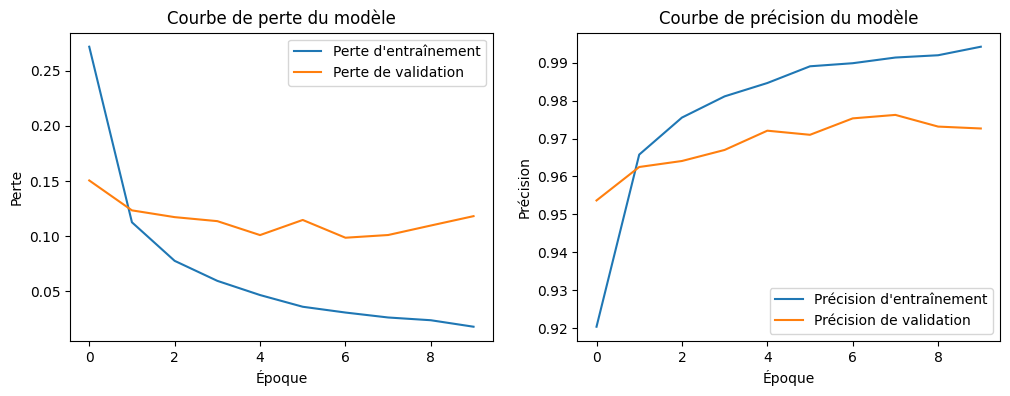

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2  # Utiliser 20% des données d'entraînement pour la validation
)

# Afficher les courbes de perte et de précision au cours de l'entraînement
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perte d\'entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.title('Courbe de perte du modèle')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision de validation')
plt.title('Courbe de précision du modèle')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.show()

## 4. Évaluer les performances du modèle

Précision sur l'ensemble de test: 0.9719
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


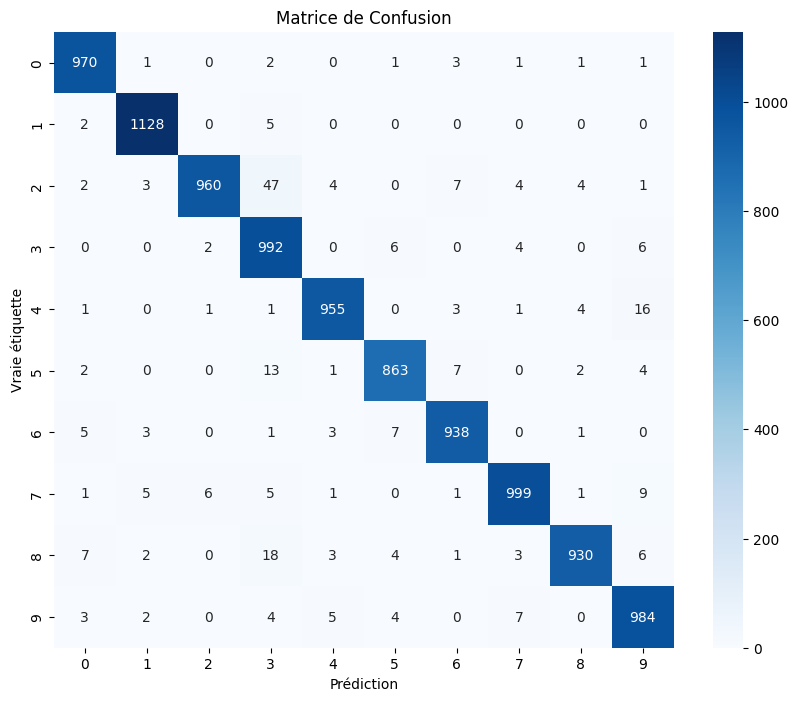

Nombre de prédictions incorrectes: 281


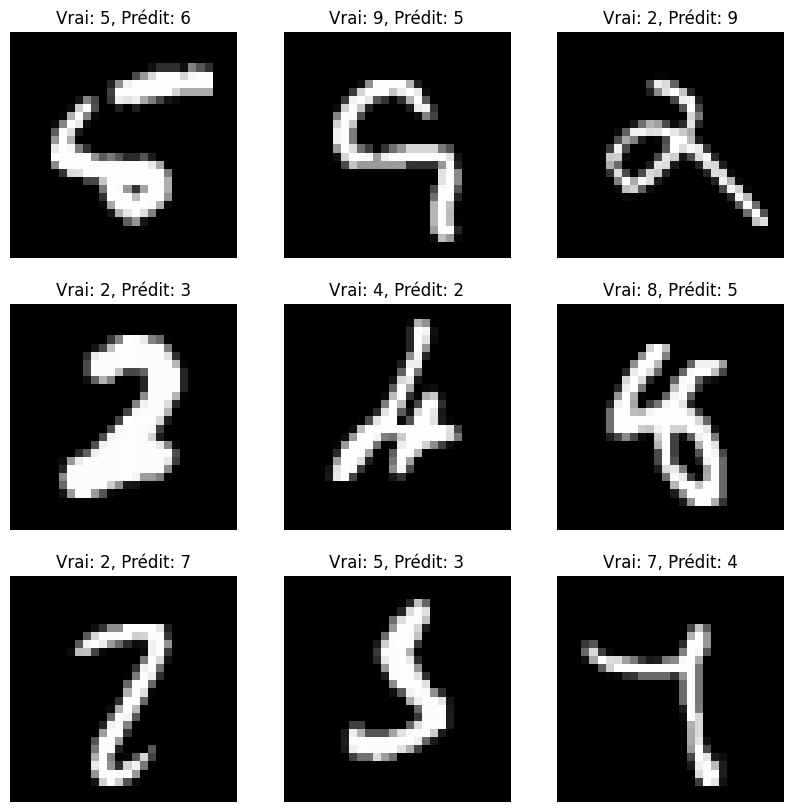

In [7]:
# Calculer la précision sur l'ensemble de données de test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Précision sur l'ensemble de test: {accuracy:.4f}")

# Afficher une matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Vraie étiquette')
plt.title('Matrice de Confusion')
plt.show()

# Identifier les chiffres avec lesquels le modèle a le plus de difficultés
# On peut analyser la matrice de confusion pour trouver les erreurs les plus fréquentes
# Par exemple, regarder les cellules hors diagonale avec les plus grandes valeurs

# Pour une analyse plus détaillée, on peut trouver les indices des prédictions incorrectes
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

print(f"Nombre de prédictions incorrectes: {len(incorrect_indices)}")

# Afficher quelques exemples d'images mal classées
plt.figure(figsize=(10, 10))
for i, incorrect in enumerate(incorrect_indices[:9]): # Afficher les 9 premières erreurs
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[incorrect], cmap='gray', interpolation='none')
    plt.title(
        f"Vrai: {y_true_classes[incorrect]}, Prédit: {y_pred_classes[incorrect]}"
    )
    plt.axis('off')
plt.show()